# Modelling

Initial setup for modelling with randomforest, histgradientboosting and xgboost.

Data output:
* [classifier.joblib](../data_generated/classifier.joblib) Trained model
* [cv_best_by_model.json](../data_generated/cv_best_by_model.json) best parameters


In [1]:
import json

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import pandas as pd
from joblib import dump
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

import mnk.substrat as subkart
import mnk

## Terrain features

In [2]:
res = subkart.features.RESOLUTION

In [3]:
gdf_sea_map = mnk.sources.sea_map_basisdata(
    #["Oslo", "Ostfold", "Akershus", "Buskerud", "Vestfold", "Rogaland", "Vestland", "More_og_Romsdal", "Trondelag"]
)
crs = gdf_sea_map.crs

In [4]:
gdf_sea_map = subkart.features.depth_preprocess(gdf_sea_map)
transform, out_shape, bounds = subkart.features.to_raster_shapes(gdf_sea_map, res=res)

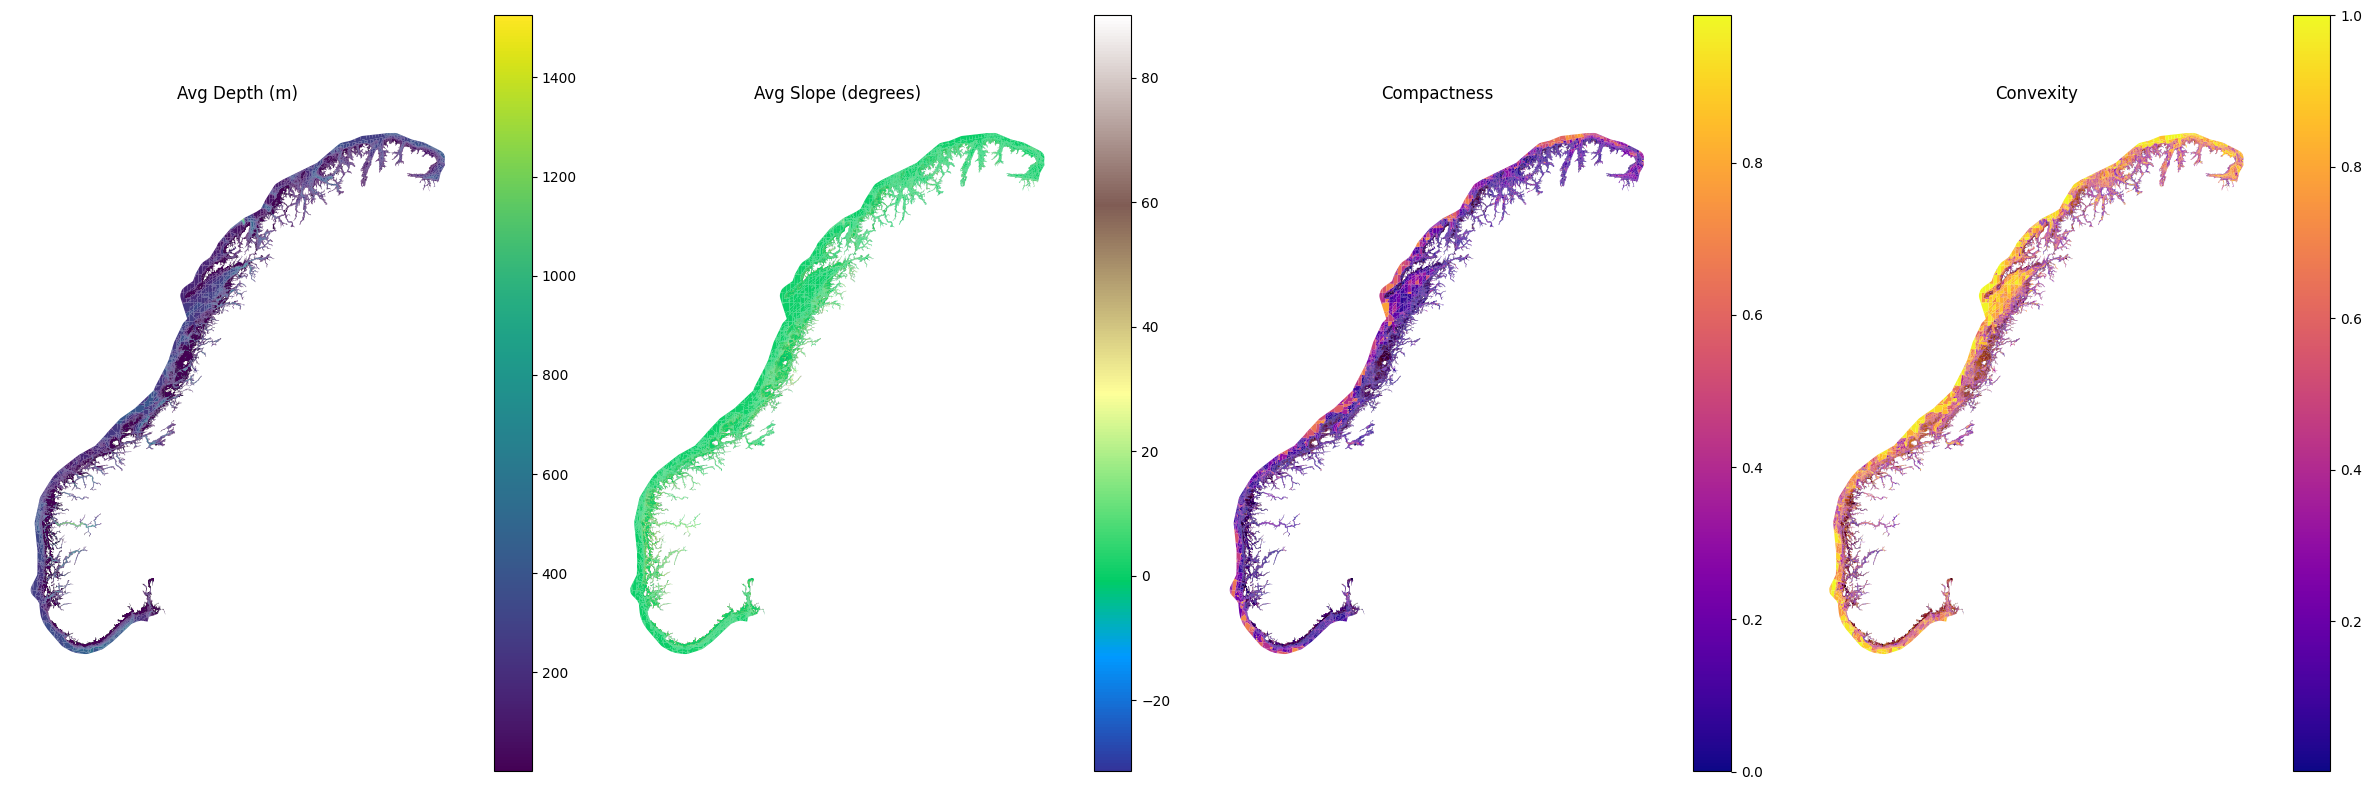

In [5]:
subkart.plot.terrain_features(gdf_sea_map)

## DEM 50

https://kartkatalog.geonorge.no/metadata/dybdedata-terrengmodeller-50-meters-grid/67a3a191-49cc-45bc-baf0-eaaf7c513549

In [6]:
dem = mnk.sources.dem_data()

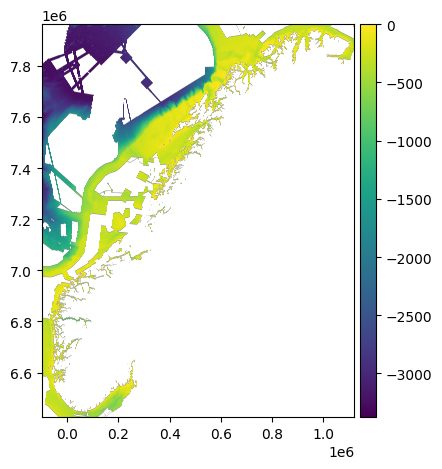

In [7]:
dem = dem.crop(bounds)
dem = subkart.utils.resample_dem(dem, out_shape, transform, crs)
dem.plot()

### Wave exposure features



In [8]:
bolge = mnk.sources.bolge_exposure()


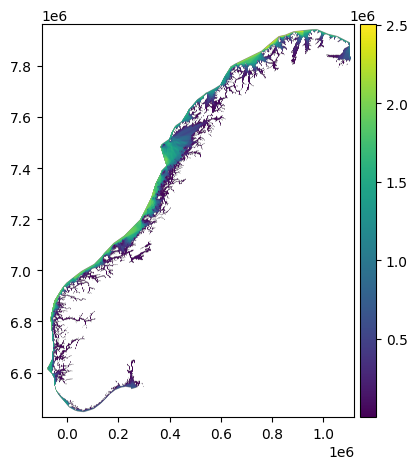

In [9]:
bolge = bolge.reproject(
    crs=crs, res=res,
    bounds=dict(left=bounds[0], bottom=bounds[1], right=bounds[2], top=bounds[3])
)
bolge.plot()

In [10]:
gdf_points = mnk.sources.depth_point_data()
print(f"Depth points: {len(gdf_points):,}")


Depth points: 6,047,001


## Dataset for labels

In [11]:
gdf_bunn_full = gpd.read_parquet(
    "gs://niva-geodata/MarintNaturKart/results/nisjedata-substrat-klassifisering_norge_latest_25833.geo.parquet"
)
gdf_bunn_full = gdf_bunn_full.dissolve(by="BunnType", as_index=False)
gdf_bunn_full["BunnType"].unique().tolist()

gdf_bunn_full = gdf_bunn_full.to_crs(crs)
bunn_raster, valid_bunn = subkart.labelling.rasterize_bunn_type(gdf_bunn_full, out_shape=out_shape, transform=transform)
del gdf_bunn_full

## Training

In [12]:
X, valid, out_shape, transform = subkart.features.build(
    dem, gdf_sea_map, bolge, valid_bunn, res=res, dtype=np.float32,
    gdf_points=gdf_points,
)

Computing interpolated depth raster...


  Point-refined 120 wide-range polygons.


Preparing sea_avg_depth...


Preparing sea_avg_slope...


/home/jovyan/marint-naturkart-niva/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


...

/home/jovyan/marint-naturkart-niva/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing sea_convexity...


/home/jovyan/marint-naturkart-niva/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing wave exposure...


Stacking feature arrays...


In [13]:
y = bunn_raster[valid]  # labels: {0,1,2}

classes = np.array(list(subkart.labelling.BUNNTYPE_MAPPING.values()), dtype=np.uint8)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)

class_weights = {int(c): float(weight) for c, weight in zip(classes, weights)}
print("Class weights:", class_weights)

# Extract geographic coordinates for each valid pixel (needed for spatial CV
# and for the spatial performance analysis in 02_performance.ipynb)
rows, cols = np.where(valid)
xs, ys = rasterio.transform.xy(transform, rows, cols)
coords = np.column_stack([xs, ys])

# Assign marine vanntyper Region (N/S/M/H/G/B) to each sample
region_labels = subkart.training.assign_region_labels(coords, crs=str(crs))
print("Region distribution:", {r: int(c) for r, c in zip(*np.unique(region_labels, return_counts=True))})

# Train/validation split — keep coords and region_labels aligned with X and y
X_train, X_val, y_train, y_val, coords_train, coords_val, region_labels_train, region_labels_val = train_test_split(
    X, y, coords, region_labels, test_size=0.2, random_state=42, stratify=y
)

# Per-sample weights based on class (class 2 fastbunn gets higher weight since it is rare)
sample_weight_train = np.array([class_weights[int(c)] for c in y_train])


Class weights: {0: 0.5534838725633138, 1: 2.1697917089426717, 2: 1.3653948201055048}


Region distribution: {'B': 1187842, 'G': 1804812, 'H': 683635, 'M': 1405867, 'N': 418167, 'S': 265407, 'unknown': 8268}


### Baseline

Train a quick baseline for each model

In [14]:
baseline_models = [
    XGBClassifier(
        num_class=len(classes),
        n_estimators=300,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=2,
        tree_method="hist",
    ),
    #HistGradientBoostingClassifier(random_state=42, class_weight=class_weights),
    #RandomForestClassifier(n_jobs=2, class_weight=class_weights, random_state=42),
]

score = 0
for base_model in baseline_models:
    m = Pipeline([("model", base_model)])
    m.fit(X_train, y_train, model__sample_weight=sample_weight_train)
    val_score = m.score(X_val, y_val)
    print(f"Baseline {type(base_model).__name__} - " f"Train: {m.score(X_train, y_train):.4f}, Val: {val_score:.4f}")
    if val_score > score:
        score = val_score
        classifier = base_model

Baseline XGBClassifier - Train: 0.7528, Val: 0.7496


## Random Search

Search through hyperparameters for each model, this can take some time

In [15]:

classifier, search_results = subkart.training.optimize_xgboost_hyperparameters(
    X_train, y_train, X_val, y_val, classes,
    class_weights=class_weights,
    region_labels=region_labels_train,
)


Starting search around existing parameters: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 1.0}


  6619 samples with unknown region included in all training folds, excluded from test folds.


Samples per region: {'B': 950219, 'G': 1443943, 'H': 546977, 'M': 1125038, 'N': 334404, 'S': 211998, 'unknown': 6619}

Starting randomized search with 50 iterations, spatial Leave-One-Region-Out (6 regions: ['B', 'G', 'H', 'M', 'N', 'S'])...
Fitting 6 folds for each of 50 candidates, totalling 300 fits


[CV] END colsample_bytree=1.0, gamma=0.08263346953150125, learning_rate=0.14187636880894328, max_depth=5, min_child_weight=8, n_estimators=478, reg_alpha=0.3974313630683448, reg_lambda=1.0165663513708072, subsample=0.9261845713819337; total time=38.6min
[CV] END colsample_bytree=1.0, gamma=0.2247253370691017, learning_rate=0.15144921397884936, max_depth=10, min_child_weight=8, n_estimators=642, reg_alpha=1.4592123566761281, reg_lambda=2.9126724140656393, subsample=0.9548850970305307; total time=59.8min


/home/jovyan/marint-naturkart-niva/.pixi/envs/default/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


...

[CV] END colsample_bytree=1.0, gamma=0.325742385928894, learning_rate=0.16480212318520945, max_depth=9, min_child_weight=2, n_estimators=602, reg_alpha=0.1888859215118568, reg_lambda=3.0490203202490704, subsample=0.6284754593840917; total time=31.6min


[CV] END colsample_bytree=1.0, gamma=0.325742385928894, learning_rate=0.16480212318520945, max_depth=9, min_child_weight=2, n_estimators=602, reg_alpha=0.1888859215118568, reg_lambda=3.0490203202490704, subsample=0.6284754593840917; total time=31.3min


[CV] END colsample_bytree=1.0, gamma=0.3442499503826832, learning_rate=0.14698323146101325, max_depth=6, min_child_weight=1, n_estimators=588, reg_alpha=0.5004857963291907, reg_lambda=2.6476799941183615, subsample=0.8858383690800249; total time=40.8min
[CV] END colsample_bytree=1.0, gamma=0.325742385928894, learning_rate=0.16480212318520945, max_depth=9, min_child_weight=2, n_estimators=602, reg_alpha=0.1888859215118568, reg_lambda=3.0490203202490704, subsample=0.6284754593840917; total time=32.8min


[CV] END colsample_bytree=1.0, gamma=0.325742385928894, learning_rate=0.16480212318520945, max_depth=9, min_child_weight=2, n_estimators=602, reg_alpha=0.1888859215118568, reg_lambda=3.0490203202490704, subsample=0.6284754593840917; total time=33.0min



Optimization complete!
Best CV score: 0.5634
CV train score: 0.7786
Train accuracy: 0.7416
Validation accuracy: 0.7395
Overfitting gap (train - val): 0.0022

Best parameters:
  colsample_bytree: 1.0
  gamma: 0.27640998845395387
  learning_rate: 0.17558121723773584
  max_depth: 6
  min_child_weight: 3
  n_estimators: 362
  reg_alpha: 0.16318836080048071
  reg_lambda: 1.0155545883219603
  subsample: 0.8511577659794545


In [16]:
dump(classifier, subkart.utils.model_dir_path() / "classifier.joblib")

['/home/jovyan/marint-naturkart-niva/model/classifier.joblib']

## Detailed evaluation

Confusion matrix, feature importance, classification report, spatial performance, and
class-1-aware ("blanding" as a mixture of løsbunn/fastbunn) adjusted metrics, computed on the
validation set (`X_val`/`y_val`/`coords_val`/`region_labels_val`) built above.

## Hyperparameter search summary

In [17]:
model_dir = subkart.utils.model_dir_path()

with open(model_dir / "xgboost_results.json", encoding="utf-8") as f:
    xgb_results = json.load(f)

class_names = [subkart.evaluation.CLASS_NAMES[c] for c in classes]



In [18]:
scores = pd.Series(
    {
        "Best CV score": xgb_results["best_score"],
        "CV train score": xgb_results["cv_train_score"],
        "Train accuracy": xgb_results["train_score"],
        "Validation accuracy": xgb_results["val_score"],
        "Overfitting gap (train - val)": xgb_results["overfitting_gap"],
    },
    name="score",
).to_frame()
scores

,score
Best CV score,0.563394
CV train score,0.778597
Train accuracy,0.741627
Validation accuracy,0.739455
Overfitting gap (train - val),0.002171


In [19]:
print("Best XGBoost hyperparameters found:")
for param, value in xgb_results["best_params"].items():
    print(f"  {param}: {value}")

Best XGBoost hyperparameters found:
  colsample_bytree: 1.0
  gamma: 0.27640998845395387
  learning_rate: 0.17558121723773584
  max_depth: 6
  min_child_weight: 3
  n_estimators: 362
  reg_alpha: 0.16318836080048071
  reg_lambda: 1.0155545883219603
  subsample: 0.8511577659794545


## Precision and accuracy explained

Two of the most common classification metrics, applied to our 3-class bottom-type problem
(0 = løsbunn, 1 = blanding, 2 = fastbunn):

* **Accuracy** — the fraction of *all* predictions that are exactly correct:

  $$\text{Accuracy} = \frac{\text{correct predictions}}{\text{total predictions}} = \frac{TP + TN}{TP + TN + FP + FN}$$

  Accuracy treats every class equally and every error equally. It can be misleading when
  classes are imbalanced, or — as here — when some errors matter less than others (see the
  "adjusted accuracy" section below).

* **Precision** (per class) — of everything the model *predicted* as a given class, the
  fraction that was actually that class:

  $$\text{Precision}_c = \frac{TP_c}{TP_c + FP_c}$$

  High precision for "fastbunn" means: when the model says a pixel is fastbunn, it usually is.
  Low precision means the model over-predicts that class (many false positives).

* **Recall** (per class, for reference) — of everything that *actually is* a given class, the
  fraction the model found:

  $$\text{Recall}_c = \frac{TP_c}{TP_c + FN_c}$$

Below we compute these directly from the validation confusion matrix so the definitions are
tied to concrete numbers for this model.

In [20]:
# Load classifier in case only evaluations are re-executed
classifier = subkart.utils.load_classifier()

In [21]:
y_val_pred = classifier.predict(X_val)

overall_accuracy = (y_val_pred == y_val).mean()
print(f"Overall accuracy: {overall_accuracy:.4f}  "
      f"({int((y_val_pred == y_val).sum())} / {len(y_val)} predictions correct)")

cm_counts = confusion_matrix(y_val, y_val_pred, labels=classes)
print("\nConfusion matrix (counts, rows=true, cols=predicted):")
print(pd.DataFrame(cm_counts, index=class_names, columns=class_names))


def print_worked_example(cm_counts, class_names, example_class_idx, display_name=None):
    """Print TP/FP/FN and the resulting precision/recall for one class, computed
    directly from the confusion matrix counts."""
    display_name = display_name or class_names[example_class_idx]
    tp = cm_counts[example_class_idx, example_class_idx]
    fp = cm_counts[:, example_class_idx].sum() - tp
    fn = cm_counts[example_class_idx, :].sum() - tp
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    print(f"\nWorked example for class '{display_name}':")
    print(f"  TP={tp}, FP={fp}, FN={fn}")
    print(f"  Precision = TP/(TP+FP) = {tp}/{tp + fp} = {precision:.4f}")
    print(f"  Recall    = TP/(TP+FN) = {tp}/{tp + fn} = {recall:.4f}")


# Worked examples: precision/recall for one class at a time, from the raw counts.
# "løsbunn" (class 0, soft bottom) is also commonly called "bløtbunn" in the field data.
print_worked_example(cm_counts, class_names, example_class_idx=0, display_name="bløtbunn (løsbunn)")
print_worked_example(cm_counts, class_names, example_class_idx=2)  # fastbunn

Overall accuracy: 0.7395  (853923 / 1154800 predictions correct)

Confusion matrix (counts, rows=true, cols=predicted):
          løsbunn  blanding  fastbunn
løsbunn    484279    103640    107554
blanding    16502    143196     17708
fastbunn    21151     34322    226448

Worked example for class 'bløtbunn (løsbunn)':
  TP=484279, FP=37653, FN=211194
  Precision = TP/(TP+FP) = 484279/521932 = 0.9279
  Recall    = TP/(TP+FN) = 484279/695473 = 0.6963

Worked example for class 'fastbunn':
  TP=226448, FP=125262, FN=55473
  Precision = TP/(TP+FP) = 226448/351710 = 0.6438
  Recall    = TP/(TP+FN) = 226448/281921 = 0.8032


## Confusion matrix and classification report

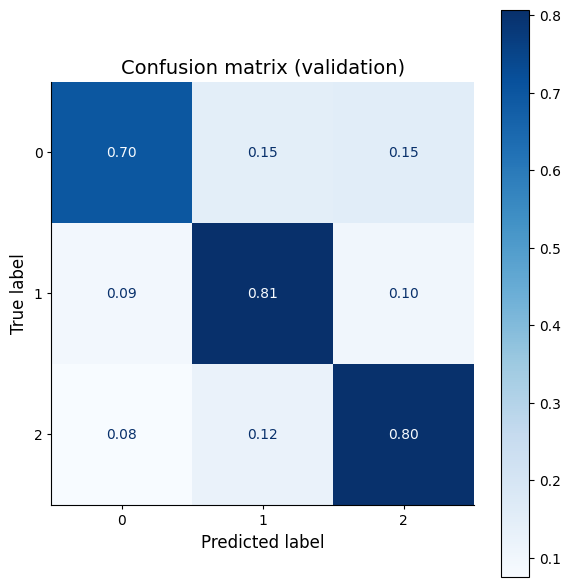

In [22]:
# Compute confusion matrix (normalized by true class)
cm = confusion_matrix(y_val, y_val_pred, labels=classes, normalize="true")
subkart.plot.confusion_matrix(cm, classes)

In [23]:
print("Classification report (validation):")
report_dict = classification_report(
    y_val,
    y_val_pred,
    labels=classes,
    target_names=class_names,
    output_dict=True,
)
report_df = pd.DataFrame(report_dict).T
report_df

Classification report (validation):


,precision,recall,f1-score,support
løsbunn,0.927858,0.696330,0.795592,6.954730e+05
blanding,0.509308,0.807165,0.624541,1.774060e+05
fastbunn,0.643849,0.803232,0.714763,2.819210e+05
accuracy,0.739455,0.739455,0.739455,7.394553e-01
macro avg,0.693672,0.768909,0.711632,1.154800e+06
weighted avg,0.794223,0.739455,0.749582,1.154800e+06


## Feature importance

dem_depth: mean=0.124934, std=0.000387
dem_slope: mean=0.087543, std=0.000348
wave_exposure: mean=0.068549, std=0.000266
sea_avg_slope: mean=0.066725, std=0.000241
sea_compactness: mean=0.052021, std=0.000229
sea_convexity: mean=0.048516, std=0.000171
dem_curvature: mean=0.047398, std=0.000221
sea_avg_depth: mean=0.033451, std=0.000246
is_dem: mean=0.004029, std=0.000029


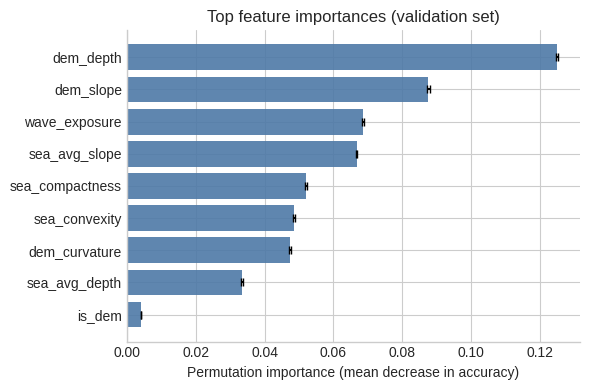

In [24]:
subkart.plot.feature_importance(classifier, X_val, y_val)

## Class-1-aware ("blanding") adjusted metrics

"Blanding" (class 1) is not an independent bottom type — it is a physical *mixture* of
løsbunn (0) and fastbunn (2). `subkart.utils.remap_prediction` even resolves "blanding"
pixels back to whichever pure class is more probable downstream. That means:

* Confusing **løsbunn ↔ blanding** or **blanding ↔ fastbunn** is a *mild* error: the pixel
  plausibly contains some of the predicted material.
* Confusing **løsbunn ↔ fastbunn** directly is a *severe* error: the model got the physical
  bottom type completely backwards.

Plain accuracy/precision/recall treat all three misclassification types identically. The
metrics below (`subkart.evaluation`) instead:

* **`adjusted_accuracy`** — accuracy where a løsbunn↔fastbunn flip costs a full error (1.0),
  but any error touching "blanding" only costs 0.25.
* **`tolerant_accuracy`** — fraction of predictions within one class of the truth (i.e. not a
  løsbunn↔fastbunn flip).
* **`severe_error_rate`** — fraction of predictions that *are* a direct løsbunn↔fastbunn flip.
* **Cohen's kappa (quadratic weighted)** — a standard ordinal-aware agreement statistic that
  penalizes distant errors (løsbunn↔fastbunn) more than adjacent ones, for comparison.

In [25]:
metrics = subkart.evaluation.summarize_metrics(y_val, y_val_pred)
metrics.to_frame(name="score")

,score
accuracy,0.739455
adjusted_accuracy,0.851275
tolerant_accuracy (±1 class),0.888548
severe_error_rate (løsbunn<->fastbunn),0.111452
cohen_kappa,0.577071
cohen_kappa (linear weighted),0.591127
cohen_kappa (quadratic weighted),0.602692


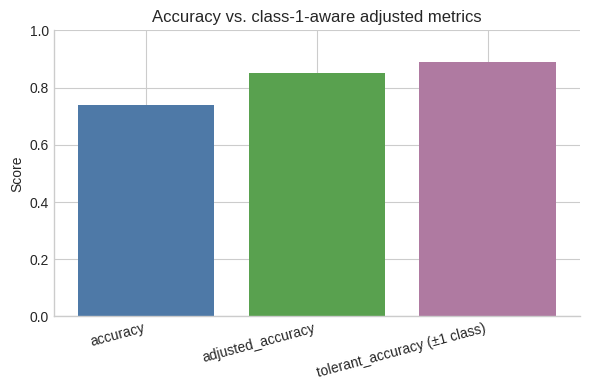

In [26]:
fig, ax = plt.subplots(figsize=(6, 4))
compare = metrics[["accuracy", "adjusted_accuracy", "tolerant_accuracy (±1 class)"]]
ax.bar(compare.index, compare.values, color=["#4e79a7", "#59a14f", "#af7aa1"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Accuracy vs. class-1-aware adjusted metrics")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## Spatial performance

How does the model perform geographically? We plot validation errors on the map (split into
mild vs. severe, per the class-1-aware definition above), and break down accuracy and
adjusted accuracy by marine vanntyper region (N/S/M/H/G/B).

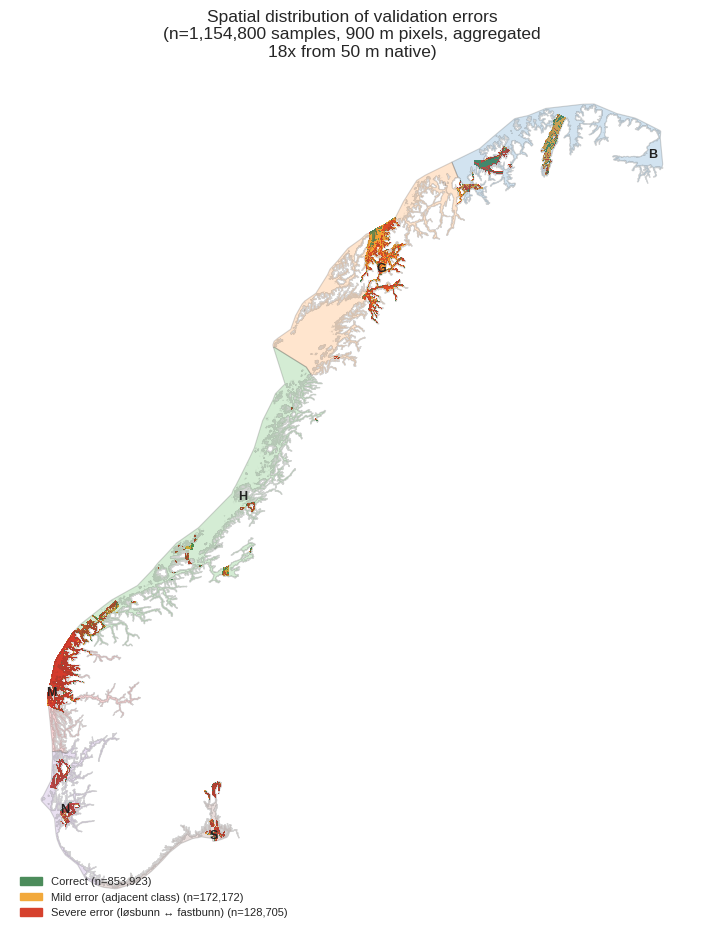

In [27]:
# Dissolved marine vanntyper region polygons, drawn as a light backdrop so errors can
# be related to region boundaries (reuses the same source as assign_region_labels above).
regions_gdf = (
    mnk.sources.marine_vanntyper()[["Region", "geometry"]]
    .dissolve(by="Region")
    .reset_index()
)

subkart.plot.spatial_errors(coords_val, y_val, y_val_pred, crs="EPSG:25833", region_gdf=regions_gdf)

In [28]:
region_df = subkart.evaluation.performance_by_region(y_val, y_val_pred, region_labels_val)
region_df

,region,n_samples,accuracy,adjusted_accuracy,severe_error_rate
0,B,237623,0.807026,0.921314,0.040590
1,G,360869,0.714686,0.889624,0.052063
2,H,136658,0.711199,0.840247,0.116737
3,M,280829,0.734500,0.770725,0.217200
4,N,83763,0.692227,0.786520,0.182049
5,S,53409,0.778389,0.834532,0.146754
6,unknown,1649,0.746513,0.829290,0.143117


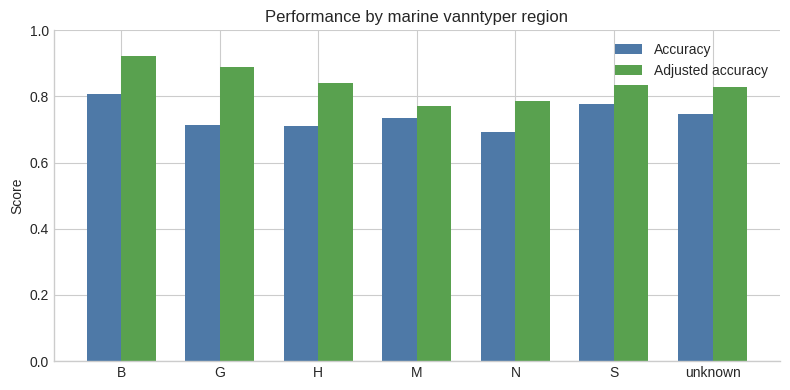

In [29]:
subkart.plot.region_performance(region_df)

## Summary

* Standard accuracy/precision/recall are reported above and computed directly from the
  validation confusion matrix.
* The class-1-aware adjusted accuracy and tolerant accuracy are consistently higher than plain
  accuracy, since they don't penalize "blanding" boundary errors as harshly as a genuine
  løsbunn↔fastbunn flip — which better reflects the real-world cost of these mistakes.
* The severe error rate (direct løsbunn↔fastbunn confusion) is a useful single number for
  tracking the "actually wrong" error rate across model iterations.
* Spatial and per-region breakdowns highlight whether errors (especially severe ones) cluster
  in particular geographic areas, which can point to missing features or under-represented
  training data in those regions.